In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('imdb_movies_2024.csv')

In [2]:
df.shape

(5099, 3)

In [3]:
df.head()

,Movie Name,Storyline,Cleaned_Storyline
0,The Substance,A fading celebrity takes a black-market drug: ...,fading celebrity takes blackmarket drug cellre...
1,The Life of Chuck,"A life-affirming, genre-bending story about th...",lifeaffirming genrebending story three chapter...
2,Bone Lake,A couple's vacation at a secluded estate is up...,couples vacation secluded estate upended theyr...
3,Anora,A young stripper from Brooklyn meets and impul...,young stripper brooklyn meets impulsively marr...
4,Eden,Based on a factual account of a group of outsi...,based factual account group outsiders settle r...


In [4]:
del df['Cleaned_Storyline']

# Pre-processing the data

In [5]:
# Removing punctuation/special characters (.!<>{}’,”(/)-)
df['Storyline'] = df['Storyline'].str.replace("[^a-zA-Z0-9]", " ", regex = True)

In [6]:
df['Storyline']

,Storyline
0,A fading celebrity takes a black market drug ...
1,A life affirming genre bending story about th...
2,A couple s vacation at a secluded estate is up...
3,A young stripper from Brooklyn meets and impul...
4,Based on a factual account of a group of outsi...
...,...
5094,Partha is a young chef in Bangalore who falls ...
5095,Two young ex lovers randomly reconnect
5096,When a man begins to use his powers for crimin...
5097,Assistant director Umashankar falls for Leo M...


In [7]:
# convert entire text from uppercase to lowercase
df['Storyline'] = [row.lower() for row in df['Storyline']]

In [8]:
df['Storyline']

,Storyline
0,a fading celebrity takes a black market drug ...
1,a life affirming genre bending story about th...
2,a couple s vacation at a secluded estate is up...
3,a young stripper from brooklyn meets and impul...
4,based on a factual account of a group of outsi...
...,...
5094,partha is a young chef in bangalore who falls ...
5095,two young ex lovers randomly reconnect
5096,when a man begins to use his powers for crimin...
5097,assistant director umashankar falls for leo m...


In [17]:
# Removing the stopwords
import nltk
#nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
stop_words = stopwords.words('english')

# Function to remove stop words
def remove_stopwords(rev):
    # take the paragraph, break into words, check if the word is a stop word, remove if stop word, combine the words into a para again
    review_tokenized = word_tokenize(rev)
    rev_new = " ".join([i for i in review_tokenized  if i not in stop_words])
    return rev_new

# Removing stopwords
df['Storyline'] = [remove_stopwords(r) for r in df['Storyline']]

print(stop_words)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

In [10]:
df.Storyline

,Storyline
0,fading celebrity takes black market drug cell ...
1,life affirming genre bending story three chapt...
2,couple vacation secluded estate upended forced...
3,young stripper brooklyn meets impulsively marr...
4,based factual account group outsiders settle r...
...,...
5094,partha young chef bangalore falls juni regular...
5095,two young ex lovers randomly reconnect
5096,man begins use powers criminal activities thre...
5097,assistant director umashankar falls leo misund...


In [11]:
# Begin Lemmatization
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('averaged_perceptron_tagger_eng')
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet

# function to convert nltk tag to wordnet tag
lemmatizer = WordNetLemmatizer()


# Convert the detailed POS tag into a shallow information
def nltk_tag_to_wordnet_tag(nltk_tag):
    if nltk_tag.startswith('J'):
        return wordnet.ADJ
    elif nltk_tag.startswith('V'):
        return wordnet.VERB
    elif nltk_tag.startswith('N'):
        return wordnet.NOUN
    elif nltk_tag.startswith('R'):
        return wordnet.ADV
    else:
        return None

# lemmatize sentence using pos tag
def lemmatize_sentence(sentence):
  # word tokenize -> pos tag (detailed) -> wordnet tag (shallow pos) -> lemmatizer -> root word
    #tokenize the sentence and find the POS tag for each token
    nltk_tagged = nltk.pos_tag(nltk.word_tokenize(sentence))
    #tuple of (token, wordnet_tag)
    wordnet_tagged = map(lambda x: (x[0], nltk_tag_to_wordnet_tag(x[1])), nltk_tagged)
    lemmatized_sentence = []
    for word, tag in wordnet_tagged:
        if tag is None:
            #if there is no available tag, append the token as is
            lemmatized_sentence.append(word)
        else:
            #else use the tag to lemmatize the token
            lemmatized_sentence.append(lemmatizer.lemmatize(word, tag))
    return " ".join(lemmatized_sentence)

df['Storyline'] = df['Storyline'].apply(lambda x: lemmatize_sentence(x))

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


In [12]:
df.Storyline

,Storyline
0,fade celebrity take black market drug cell rep...
1,life affirm genre bend story three chapter lif...
2,couple vacation seclude estate upend force sha...
3,young stripper brooklyn meet impulsively marri...
4,base factual account group outsiders settle re...
...,...
5094,partha young chef bangalore fall juni regular ...
5095,two young ex lover randomly reconnect
5096,man begin use power criminal activity threaten...
5097,assistant director umashankar fall leo misunde...


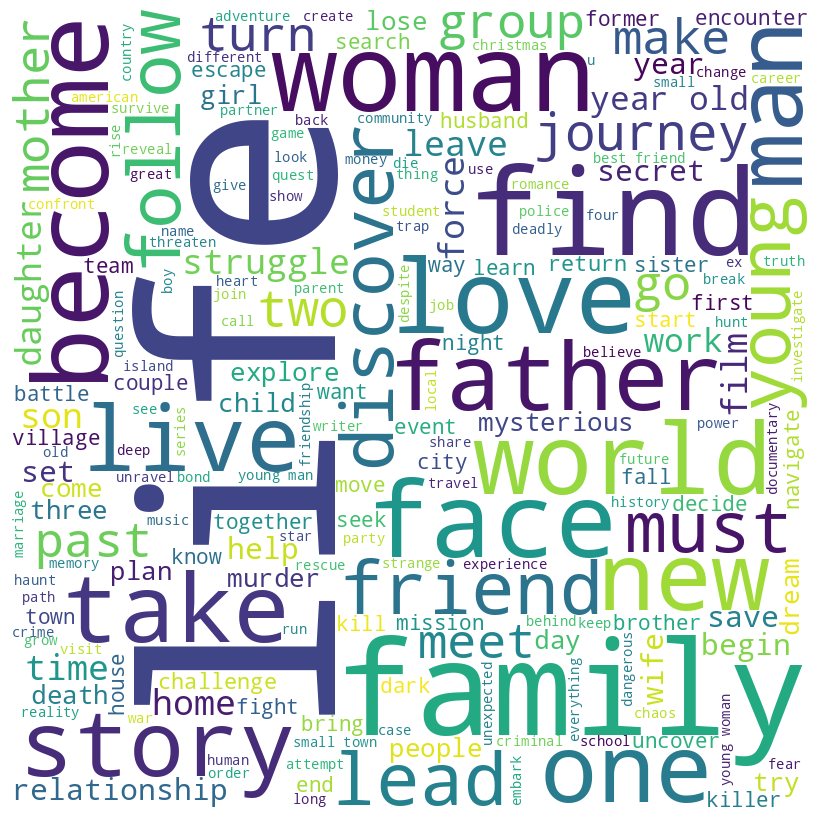

In [13]:
from wordcloud import WordCloud

# Directly use the 'Storyline' column from the DataFrame
all_words = ' '.join([text for text in df['Storyline']])

wordcloud = WordCloud(width = 800, height = 800,
                      background_color ='white',
                      min_font_size = 10).generate(all_words)

#plot the WordCloud image
plt.figure(figsize = (8, 8), facecolor = None)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad = 0)
plt.show()

In [16]:
# Cosine similarity
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import joblib

tfidf =TfidfVectorizer(max_features=2500)
X = tfidf.fit_transform(df['Storyline']).toarray()

def find_similar_storylines(new_story_text, dataframe, vectrizer, X_matrix, top_n=10):

  query_vector = vectrizer.transform([new_story_text]).toarray()
  similarity_scores = cosine_similarity(query_vector, X_matrix).flatten()
  top_indices = similarity_scores.argsort()[-top_n:][::-1]
  similar_storylines = dataframe.iloc[top_indices]
  return similar_storylines


input_query = "fade celebrity take black market drug cell rep"

#print(f"Input Query: {input_query}\n")

similar_storylines = find_similar_storylines(input_query, df, tfidf, X)
print(f"Similar Storylines:\n{similar_storylines}")

#Saved as a joblib file
joblib.dump(tfidf, "tfidf_vectorizer.joblib")
joblib.dump(X, "tfidf_matrix.joblib")
joblib.dump(df, "movies_dataframe.joblib")

Similar Storylines:
                     Movie Name  \
0                 The Substance   
3274     Everybody Loves Jenifa   
4122                  Seditiosa   
642     The Southern Chronicles   
1847  Curse of the Seven Oceans   
1195   Bogota: City of the Lost   
4594          Look to the Light   
2205   The Burden of Nine Lives   
3665             Fit for Murder   
3033            Was Once a Hero   

                                              Storyline  
0     fade celebrity take black market drug cell rep...  
3274  jenifa popularity fade shady new neighbor lobs...  
4122  yahel companion judith magdalena way market en...  
642   follow rimants interested play rugby listen mu...  
1847  start trade competition market people use supe...  
1195  young man move colombia family well life end l...  
4594  life wannabe celebrity influencer take tragic ...  
2205  witness two close cousin execute black market ...  
3665  base actual event live fitness celebrity craig...  
3033  ginny li

['movies_dataframe.joblib']

In [15]:
# Euclidean distances
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import euclidean_distances

tfidf = TfidfVectorizer(max_features=2500)
X = tfidf.fit_transform(df['Storyline']).toarray()

def find_similar_storylines_euclidean(new_story_text, dataframe, vectrizer, X_matrix, top_n=10):
    query_vector = vectrizer.transform([new_story_text]).toarray()
    distances = euclidean_distances(query_vector, X_matrix).flatten()
    top_indices = distances.argsort()[:top_n]

    # Get the similar storylines and their corresponding distances
    similar_storylines_df = dataframe.iloc[top_indices].copy()
    relevant_distances = distances[top_indices]
    similar_storylines_df['Euclidean_Distance_Score'] = relevant_distances

    return similar_storylines_df


input_query = "fade celebrity take black market drug cell rep"

similar_storylines_euclidean_df = find_similar_storylines_euclidean(input_query, df, tfidf, X)

print("\n -- Relevant matches found with distance score\n")

for index, row in similar_storylines_euclidean_df.iterrows():
    print(f"Distance Score: {row['Euclidean_Distance_Score']:.4f}")
    print(f"Storyline: {row['Storyline']}")
    print("-" * 30)


 -- Relevant matches found with distance score

Distance Score: 0.6678
Storyline: fade celebrity take black market drug cell replicate substance help create young good version
------------------------------
Distance Score: 1.1729
Storyline: jenifa popularity fade shady new neighbor lobster outshines charity work ghana jenifa friends face deadly drug baron bag drug mistakenly leave rental
------------------------------
Distance Score: 1.2080
Storyline: yahel companion judith magdalena way market end confront roman religious authority begin long walk market turn cruel journey cross
------------------------------
Distance Score: 1.2118
Storyline: follow rimants interested play rugby listen music deal black market study school fall love monika faith love future test
------------------------------
Distance Score: 1.2225
Storyline: start trade competition market people use supernatural thing perform black magic bring rival
------------------------------
Distance Score: 1.2305
Storyline: you